Loaded OGBNARXIV dataset!
Subset has 6 nodes. Now plotting across edge types...


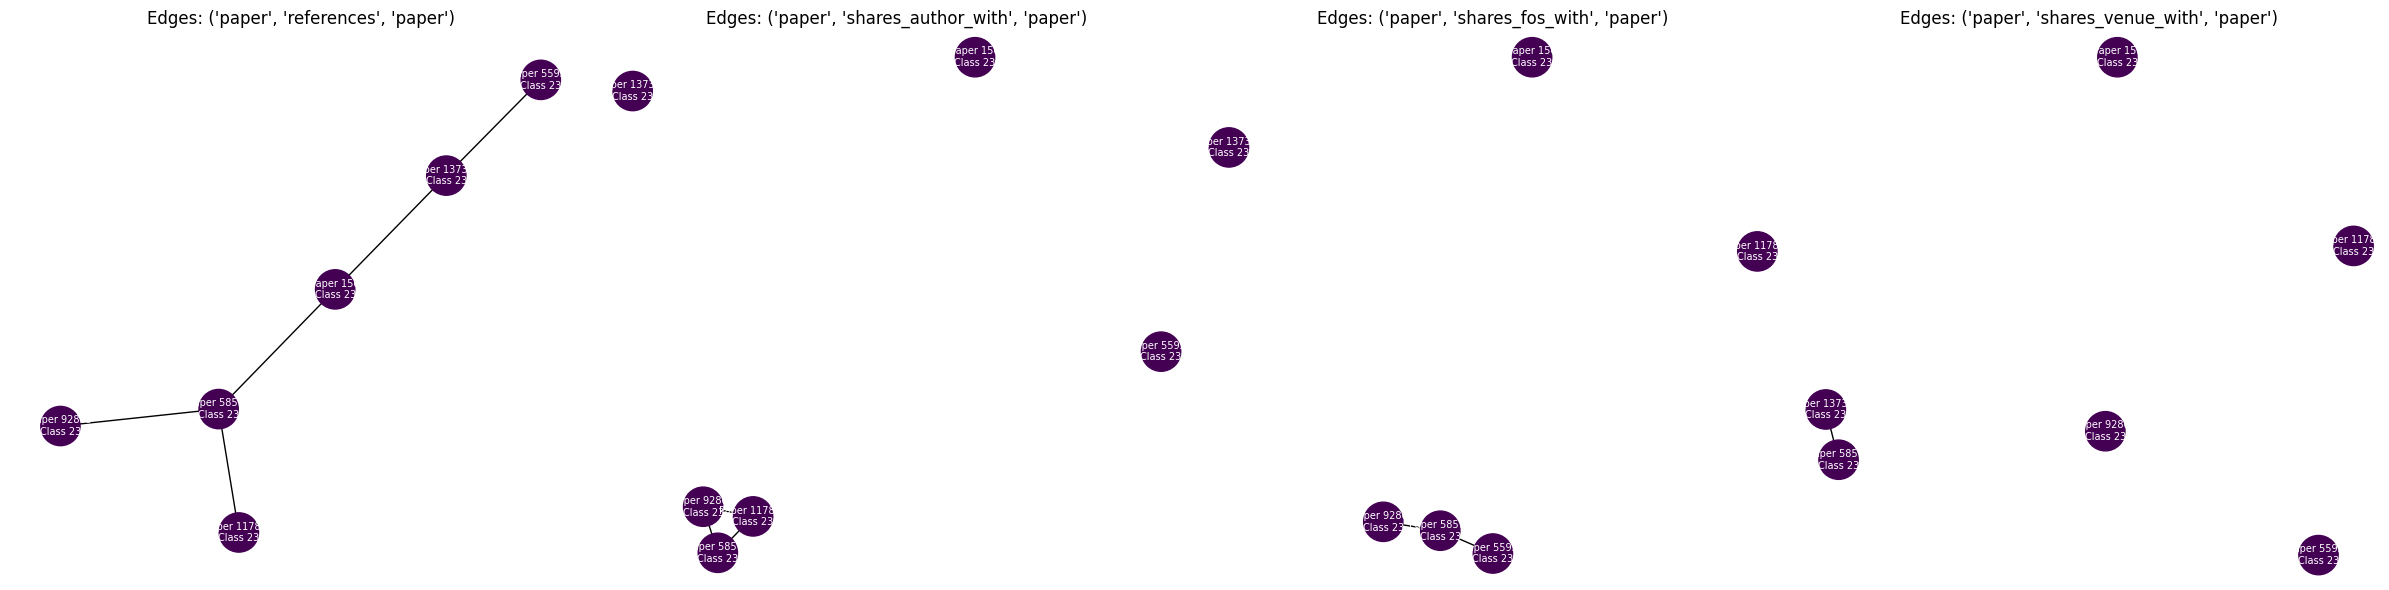

In [9]:
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx, to_edge_index, k_hop_subgraph
from torch_geometric.data import Data
import sys
import random

# ===================================================================
dataset_name = "ogbnarxiv"   # or 'pubmed'
center_node_idx = 150
max_nodes = 20   # 👈 fewer nodes for readability
# ===================================================================

# --- Load dataset ---
filepath = f"data/{dataset_name}_heterodata.pt"
try:
    data = torch.load(filepath, weights_only=False)
    print(f"Loaded {dataset_name.upper()} dataset!")
except FileNotFoundError:
    print(f"Dataset file not found at {filepath}. Run 'multigraph.py' first.")
    sys.exit()

node_labels = data["paper"].y.squeeze()

# --- Step 1: Get the node subset from "references" relation (as anchor) ---
edge_index_ref, _ = to_edge_index(data[("paper","references","paper")].adj_t)
subset_nodes, _, _, _ = k_hop_subgraph(
    node_idx=center_node_idx,
    num_hops=2,
    edge_index=edge_index_ref,
    relabel_nodes=False
)

# If too many nodes → sample down
if len(subset_nodes) > max_nodes:
    sampled = set(random.sample(subset_nodes.tolist(), max_nodes))
    sampled.add(center_node_idx)
    subset_nodes = torch.tensor(sorted(sampled))

print(f"Subset has {len(subset_nodes)} nodes. Now plotting across edge types...")

# --- Step 2: Plot each edge type separately ---
edge_types = data.edge_types
n_types = len(edge_types)
fig, axes = plt.subplots(1, n_types, figsize=(6*n_types, 6))

if n_types == 1:
    axes = [axes]  # make iterable

for ax, edge_type in zip(axes, edge_types):
    # Extract edge_index for this relation
    edge_index, _ = to_edge_index(data[edge_type].adj_t)

    # Keep only edges where both ends are in subset_nodes
    mask = torch.tensor([
        (u.item() in subset_nodes.tolist()) and (v.item() in subset_nodes.tolist())
        for u,v in edge_index.T
    ])
    sub_edge_index = edge_index[:, mask]

    # Remap nodes for compact graph
    node_map = {nid.item(): i for i, nid in enumerate(subset_nodes)}
    remapped_edges = torch.tensor([
        [node_map[u.item()], node_map[v.item()]] for u,v in sub_edge_index.T
    ]).T if sub_edge_index.size(1) > 0 else torch.empty((2,0),dtype=torch.long)

    # Build Data → NetworkX
    subgraph_data = Data(edge_index=remapped_edges, num_nodes=len(subset_nodes))
    G = to_networkx(subgraph_data, to_undirected=True)

    # Labels
    node_labels_dict = {
        i: f"Paper {nid.item()}\nClass {node_labels[nid].item()}"
        for i, nid in enumerate(subset_nodes)
    }

    # Draw
    pos = nx.spring_layout(G, seed=42)
    nx.draw(
        G, pos,
        with_labels=True,
        labels=node_labels_dict,
        node_color=[node_labels[nid].item() for nid in subset_nodes],
        cmap="viridis",
        node_size=800,
        font_size=7,
        font_color="white",
        ax=ax
    )
    ax.set_title(f"Edges: {edge_type}")

plt.tight_layout()
plt.show()


Loaded PUBMED dataset!
Subset has 7 nodes. Now plotting across edge types...


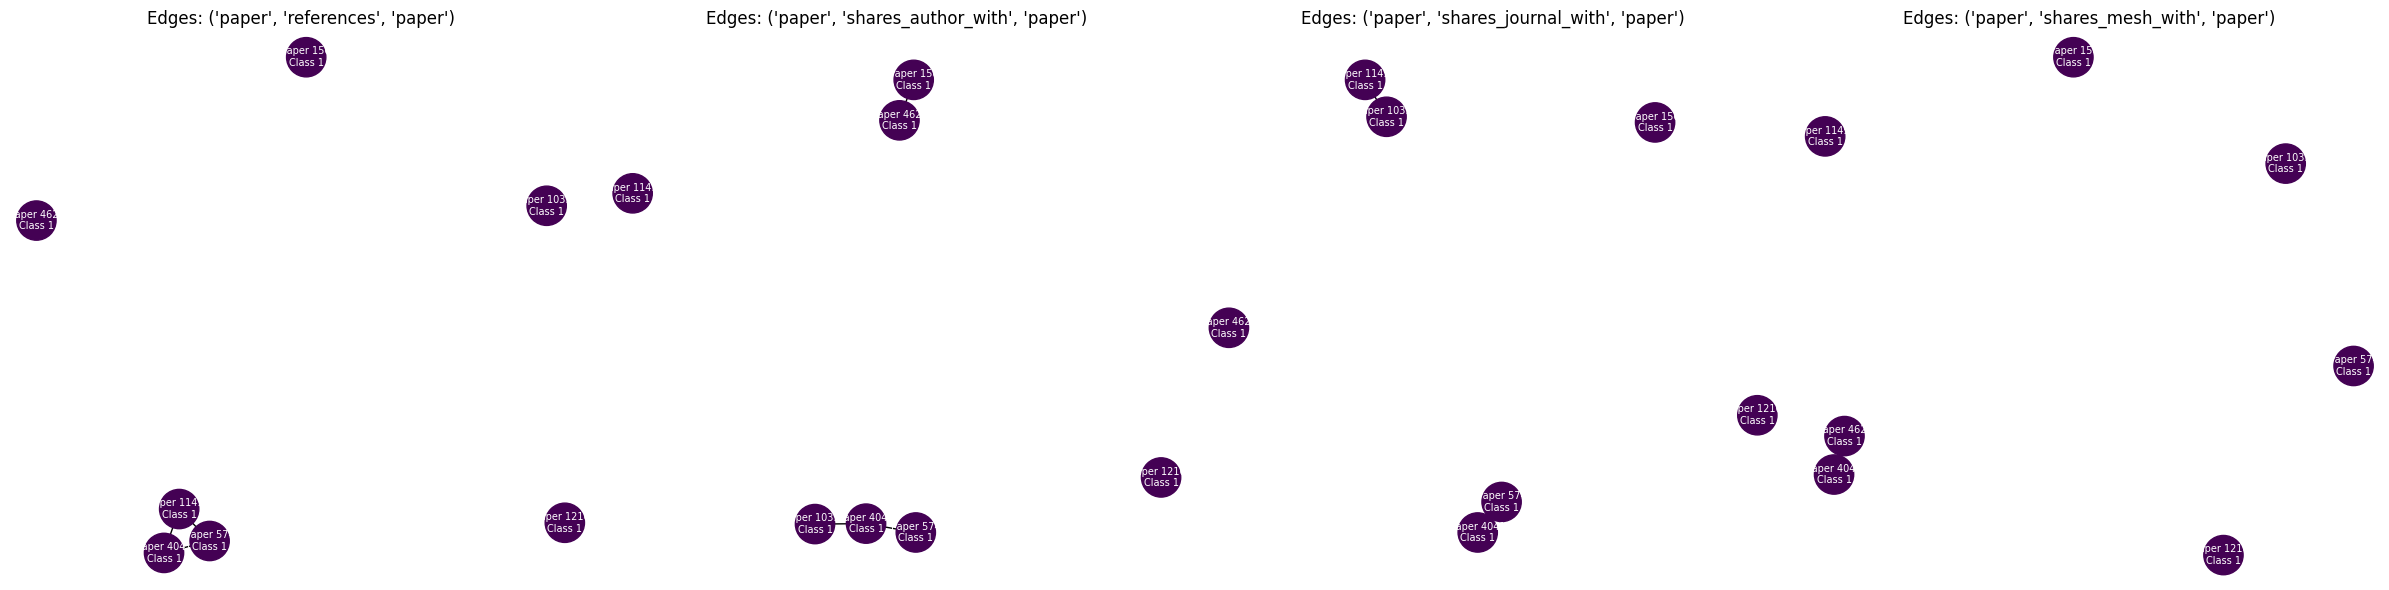

In [11]:
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx, to_edge_index, k_hop_subgraph
from torch_geometric.data import Data
import sys
import random

# ===================================================================
# --- MODIFICATION: Set the dataset to 'pubmed' ---
dataset_name = "pubmed"      # Changed from 'ogbnarxiv'
# ===================================================================

# --- You can adjust these parameters if you like ---
center_node_idx = 150        # A valid node ID in the PubMed dataset
max_nodes = 6               # Keep the graph readable

# --- Load dataset ---
filepath = f"data/{dataset_name}_heterodata.pt"
try:
    data = torch.load(filepath, weights_only=False)
    print(f"Loaded {dataset_name.upper()} dataset!")
except FileNotFoundError:
    print(f"Dataset file not found at {filepath}. Run 'multigraph.py' first.")
    sys.exit()

node_labels = data["paper"].y.squeeze()

# --- Step 1: Get the node subset from "references" relation (as anchor) ---
# This edge type is common to both datasets
edge_index_ref, _ = to_edge_index(data[("paper","references","paper")].adj_t)
subset_nodes, _, _, _ = k_hop_subgraph(
    node_idx=center_node_idx,
    num_hops=2,
    edge_index=edge_index_ref,
    relabel_nodes=False
)

# If too many nodes → sample down
if len(subset_nodes) > max_nodes:
    sampled = set(random.sample(subset_nodes.tolist(), max_nodes))
    sampled.add(center_node_idx) # Ensure the center node is always included
    subset_nodes = torch.tensor(sorted(sampled))

print(f"Subset has {len(subset_nodes)} nodes. Now plotting across edge types...")

# --- Step 2: Plot each edge type separately ---
edge_types = data.edge_types
n_types = len(edge_types)
fig, axes = plt.subplots(1, n_types, figsize=(6*n_types, 6))

if n_types == 1:
    axes = [axes]  # make iterable

for ax, edge_type in zip(axes, edge_types):
    # Extract edge_index for this relation
    edge_index, _ = to_edge_index(data[edge_type].adj_t)

    # Keep only edges where both ends are in subset_nodes
    mask = torch.tensor([
        (u.item() in subset_nodes.tolist()) and (v.item() in subset_nodes.tolist())
        for u,v in edge_index.T
    ])
    sub_edge_index = edge_index[:, mask]

    # Remap nodes for compact graph
    node_map = {nid.item(): i for i, nid in enumerate(subset_nodes)}
    remapped_edges = torch.tensor([
        [node_map[u.item()], node_map[v.item()]] for u,v in sub_edge_index.T
    ]).T if sub_edge_index.size(1) > 0 else torch.empty((2,0),dtype=torch.long)

    # Build Data → NetworkX
    subgraph_data = Data(edge_index=remapped_edges, num_nodes=len(subset_nodes))
    G = to_networkx(subgraph_data, to_undirected=True)

    # Labels
    node_labels_dict = {
        i: f"Paper {nid.item()}\nClass {node_labels[nid].item()}"
        for i, nid in enumerate(subset_nodes)
    }

    # Draw
    pos = nx.spring_layout(G, seed=42)
    nx.draw(
        G, pos,
        with_labels=True,
        labels=node_labels_dict,
        node_color=[node_labels[nid].item() for nid in subset_nodes],
        cmap="viridis",
        node_size=800,
        font_size=7,
        font_color="white",
        ax=ax
    )
    ax.set_title(f"Edges: {edge_type}")

plt.tight_layout()
plt.show()